Monte Carlo simulation is appropriate when the business doesn't have much data.

Or B2B businessses where orders are placed years in advance.

Monte Carlo simulation is useful when demand is difficult to forecast. Or when demand is random. 

Useful analytical solutions are not possible if data is truly random. There are no patterns for me to necessarily find.

An analytical solution would be a probabilistic model like linear regression. 

With monte carlo simulations, we can simulate what the output environment looks like.

Three steps for Monte Carlo simulation

1. Generate the random variables
2. Compute the value of the function for each value of generated random variables.
3. Compute statistics that tell us about the reliability of the data.

Monte carlo simulation tells us the likelihood of what scenarios could occur. It simulates behaviour but doesn't tell us what to do.

Monte carlo simulates what demand could occur. Based on the 10,000 or simulations we get probability values. we know any given week, demand equals 3 is the most likely thing that will happen, but it is not for sure just because it has 41% probability. Once we simulate all the data, we now need to model what revenue will be for a given week. 

We need to make a decision on what the simulated data means for the business. 

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
values = np.array([1,2,3,4,5,6,7,8])
hits = np.array([12,13,43,65,10,5,4,3])

probs = hits / np.sum(hits) # probabilities of each of these demand scenarios happening
probs

array([0.07741935, 0.08387097, 0.27741935, 0.41935484, 0.06451613,
       0.03225806, 0.02580645, 0.01935484])

In [8]:
cum_probs = np.cumsum(probs)
cum_probs

array([0.07741935, 0.16129032, 0.43870968, 0.85806452, 0.92258065,
       0.95483871, 0.98064516, 1.        ])

In [9]:
random_variable = np.random.uniform(0,1,1) # generating a random variable between zero and one

index_value = min(np.argwhere(cum_probs > random_variable).ravel()) # this gives the index value of the row that the RV lies between lower and upper bounds

assigned_value = values[index_value] # the assigned value

In [10]:
assigned_value

4

In [ ]:
# calculating the profit function for this variable
profit = 3 * (assigned_value < 5) + 5 * (assigned_value >= 5) # (assigned < 5) returns a true or false value which will be true and thus equal to 1

list([random_variable.ravel(), assigned_value, profit])

[array([0.61476561]), 4, 3]

workflow so far: generate some probabilities of different outcomes, then we select an observation and predict profit

need to write a loop that will run this simulation

there isn't a universal monte carlo simulation method in programming. 

In [ ]:
# generating a sample of 1000 RVs and we'll see the profit for each variable then I'll calculate the averages

m = 1000 # running the simulation 1000 times
N = 100

random_variable = np.random.uniform(0,1,[m, N])

profit_values = np.zeros((m, N))

for i in range(N):
    profit_m = [] # aggregating the data here, the average profitability of 1000 runs
    # the average of averages keeps the distribution tight and to get a more representative value of what the profitability likely to be based off of this random simulation
    for j in range(m):
        # think of this block as one experiment then we do it 1000 times then we do 100 runs of this experiment
        index_value = min(np.argwhere(cum_probs > random_variable[j, i]).ravel()) # selecting which index to use
        assigned_value = values[index_value]
        profit_val = 3 * (assigned_value < 5) + 5 * (assigned_value >= 5)
        profit_m.append(profit_val)
    profit_values[:,i] = profit_m # the average of the 100 runs with each run having 1000 experiments


In [ ]:
mean_sample = np.mean(profit_values, axis=0)

sigma = np.std(mean_sample)

f_bar_bar = np.mean(mean_sample)

lower_bound = f_bar_bar - 1.96 * sigma / np.sqrt(N)

upper_bound = f_bar_bar + 1.96 * sigma / np.sqrt(N)

list[lower_bound, f_bar_bar, upper_bound] # summary statistics

list[3.2799062767867446, 3.2845, 3.2890937232132553]

the uniform distribution is about sampling so each sample has an equal chance of being selected. 

demand = 4 is the most likely to happen because it has the highest probability. 

We use a uniform distribution so it's a random sample of the demand variables and not just demand = 4 because it has the highest probability. 

The simulation still respects the cumulative distribution of where an observation might fall. The uniform distribution ensures equal weight to each possible outcome for demand from 1 to 8.

run something like this and estimate demand to inform how much product we order. and we see what happens. But now I can start collecting data and over time it will start improving my estimates. Monte carlo is a way of quantifying uncertainty.

If i have assumptions of the probability of different demands happening i can use any probability distributions. This requires domain knowledge, emprical historical data and I have some sense of how the data behaves. Can test with different distributions to learn more about the data.

<Axes: ylabel='Count'>

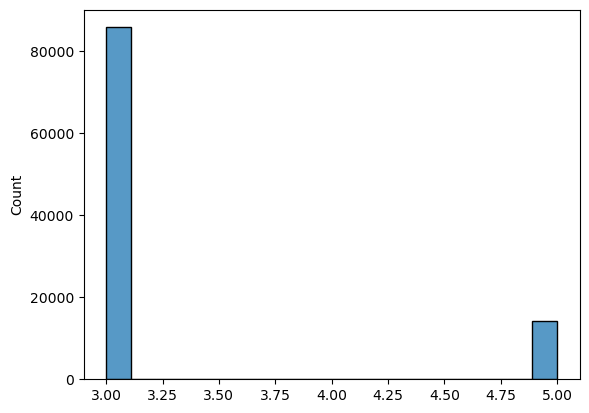

In [25]:
sns.histplot(profit_values.ravel())

In [36]:
# new example

demand = np.array([0,1,2,3,4,5])

frequency = np.array([15,30,60,120,45,30])

demand_probs = frequency / np.sum(frequency)

demand_cum_probs = np.cumsum(demand_probs)

In [37]:
lead_time = np.array([1,2,3])

frequency = np.array([10,25,15])

lead_time_probs = frequency / np.sum(frequency)

lead_time_cum_probs = np.cumsum(lead_time_probs)

In [38]:
Q = 10

R = 5

I = 10

EI = []

LS = []

lead_time_new = 0

order = False # by default we don't order

daily_cost = []

In [39]:
m = 1000

for i in range(m):
    if (order==True):
        lead_time_new = lead_time_new - 1 # if we need to order we take the probability of the lead time
        if (lead_time_new==0):
            I = I + Q # inventory plus the quantity ordered if we don't need to order
            order=False
        demand_rv = np.random.uniform(0,1,1)
        index_value = min(np.argwhere(demand_cum_probs > demand_rv).ravel())
        demand_realized = demand[index_value]
        EI.append(max(0, I - demand_realized))
        LS.append(max(0, demand_realized - I))
        mismatch_cost = 0.5 * EI[-1] + 8 * LS[-1] # last value of lost sales
        ordering_cost = 0
        I = EI[-1]
        if (I < R and order==False):
            lead_time_rv = np.random.uniform(0,1,1)
            index_value = min(np.argwhere(lead_time_cum_probs > lead_time_rv).ravel())
            lead_time_realized = lead_time[index_value]
            lead_time_new = lead_time_realized
            order=True
            ordering_cost = 10
        daily_cost.append(mismatch_cost + ordering_cost)

In [40]:
# the real simulation. we're predicting cost of holding inventory. 
# We predicted the average total daily inventory cost. we expect on average COGS to be $7. Then from here as a management team decide if that's good or bad depending on profit

# Let's develop the MC simulation for 1000 days and 100 iteration
m = 1000
N = 100 
daily_cost_values = np.zeros((m,N))
for i in range(N):
    Q = 10
    R = 5
    I = 10
    EI = []
    LS = []
    lead_time_new = 0
    order = False
    daily_cost = []
    for j in range(m):
        if (order==True):
            lead_time_new = lead_time_new - 1
            if (lead_time_new==0):
                I = I + Q
                order= False
        demand_rv = np.random.uniform(0,1,1)
        index_value = min(np.argwhere(demand_cum_probs>demand_rv).ravel())
        demand_realized = demand[index_value]
        EI.append(max(0,I-demand_realized))
        LS.append(max(0,demand_realized-I))
        mismatch_cost = 0.5*EI[-1]+8*LS[-1]
        ordering_cost = 0
        I = EI[-1]
        if (I<R and order==False):
            lead_time_rv = np.random.uniform(0,1,1)
            index_value = min(np.argwhere(lead_time_cum_probs>lead_time_rv).ravel())
            lead_time_realized = lead_time[index_value]
            lead_time_new = lead_time_realized
            order=True
            ordering_cost = 10
        daily_cost.append(mismatch_cost+ordering_cost)
    daily_cost_values[:,i]=daily_cost

# calculate the mean of each sample
mean_sample = np.mean(daily_cost_values, axis = 0)
# calculate standard deviation
sigma = np.std(mean_sample)
# Mean of means
f_bar_bar = np.mean(mean_sample)
# Lower bound of CI
lower_bound = f_bar_bar-1.96*sigma/np.sqrt(N)
# Upper bound of CI
upper_bound = f_bar_bar+1.96*sigma/np.sqrt(N)
# Summary statistics Lower Bound, Mean of Means, Upper Bound
list[lower_bound,f_bar_bar,upper_bound]



list[6.985623332310575, 7.0204650000000015, 7.055306667689428]